# Linear Regression
**Dataset:** Salary Data  
**Feature:** Years of Experience  
**Target:** Salary

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Note: StandardScaler is not needed for simple linear regression
# from sklearn.preprocessing import StandardScaler

## 2. Data Loading

In [ ]:
# Load the Salary dataset
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

df = load_data('Salary_Data.csv')

## 3. Data Exploration

In [6]:
# Statistical summary of all columns
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [ ]:
# Dataset info: row/column count, data types, and missing value overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


## 4. Data Cleaning and Preprocessing

In [ ]:
# Check for missing and duplicate values
def check_missing(df):
    null_val = df.isnull().sum()   # count null values per column
    dup_val  = df.duplicated().sum()  # count duplicate rows
    return null_val, dup_val

check_missing(load_data('Salary_Data.csv'))

## 5. Feature Selection

In [ ]:
# Select feature (X) and target (Y)
# Double brackets keep both as 2-D DataFrames
feature = df[['YearsExperience']]
target  = df[['Salary']]

feature.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


## 6. Train / Test Split and Model Training

In [ ]:
# Split into 80 % training and 20 % testing sets
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=42
)

# Train the linear regression model
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 7. Regression Line Visualisation

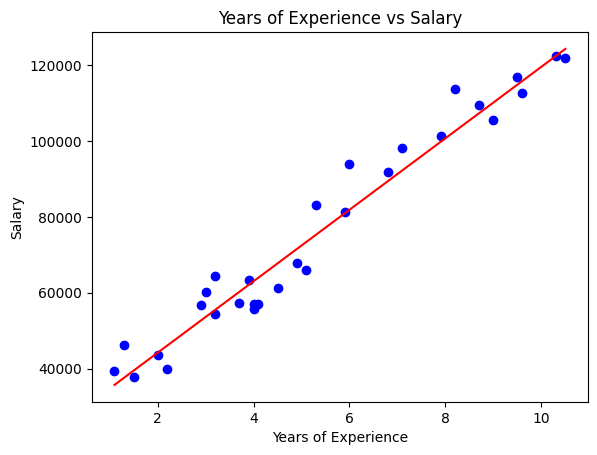

In [ ]:
# Scatter plot of data points with the fitted regression line
plt.scatter(feature, target, color='blue', label='Actual data')
plt.plot(feature, model.predict(feature), color='red', label='Regression line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.legend()
plt.show()

## 8. Loss Function and Evaluation Metrics

In [ ]:
# Predict on the test set
y_pred = model.predict(x_test)

# Mean Squared Error — average squared difference between actual and predicted values
mse = mean_squared_error(y_test, y_pred)

# R² Score — proportion of variance in the target explained by the model (1.0 = perfect)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:,.2f}')
print(f'R² Score          : {r2:.4f}')

Mean Squared Error: 49830096.85590839
R^2 Score: 0.9024461774180497


## 9. Model Interpretation

In [ ]:
# Coefficients and intercept of the fitted model
print(f'Coefficient : {model.coef_[0][0]:,.2f}')
print(f'Intercept   : {model.intercept_[0]:,.2f}')

# Coefficient: the change in Salary for each additional year of experience
# Intercept  : the estimated salary when years of experience is zero

Coefficients: [[9423.81532303]]
Intercept: [25321.58301178]
